## Import Libraries for Heatmap generation

1) Plot without clustering
2) Split each feature into 3 different layers:
	1) Spatial, Texture, Intensity
	2) Cell Region
	3) SER-edge or STAR feature

#### z-scores: blue=low, white=mean, red=high.

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import re
from matplotlib.patches import Patch

In [3]:
rng = np.random.default_rng(seed=42)

In [4]:
from sklearn.preprocessing import StandardScaler

# Initialise Data Path

In [5]:
data_path = 'data/Raw_Data_Batch1_LAB1_CTX2.csv'
counts = pd.read_csv(data_path)
counts = counts.drop(columns=[
                   	"Row",
                    "Column",
                    "Timepoint",
                    "Field",
                    "Object No",
                    "X",
                    "Y",
                    "Bounding Box",
                    "Batch",
                    "Nuclei - Object No in Nuclei_all",
                    "Cellline ID"
                   ])
# Double check here
counts = counts.drop(columns=[
    'Position X [Âµm]',
	'Position Y [Âµm]',
    'Compound',
    'Concentration',
    'Cell Count'
])
print("counts (before): ", counts.shape)
counts = counts.fillna(0)
print("counts (after): ", counts.shape)

counts (before):  (20682, 1321)
counts (after):  (20682, 1321)


### For filtering specific variants

In [6]:
counts.head()

,Cell Type,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,Control,1964.49,473.458,2001,2964,747,1092250,24.1009,2558,0.547062,...,0.062429,0.055786,0.060275,0.080337,0.692103,0.179664,0.246843,0.195137,0.000550,0.004230
1,Control,2582.91,555.290,2683,3507,1303,883355,21.4986,3261,0.674363,...,0.056252,0.055994,0.062334,0.067784,0.661050,0.187395,0.229586,0.210063,0.000543,0.004167
2,Control,3105.96,806.695,2904,6924,1006,2963080,25.9725,4097,0.466701,...,0.047268,0.060245,0.063949,0.054644,0.708571,0.196272,0.287673,0.203688,0.000483,0.003577
3,Control,1677.06,552.588,1557,3253,779,753001,32.9498,2438,0.286715,...,0.084388,0.079462,0.080827,0.100119,0.681948,0.367140,0.485384,0.179421,0.000649,0.005440
4,Control,3321.61,796.328,3175,9111,1523,4354630,23.9741,4097,0.425068,...,0.057507,0.053676,0.054210,0.068928,0.770866,0.165035,0.318869,0.227847,0.000484,0.003702


In [7]:
counts[['Lysosome Spatial - Outer region Profile 3/5', 'Lysosome Spatial - Outer region Profile 3/5 SER-Dark', 'Lysosome Spatial - Outer region Profile 3/5 SER-Ridge', 'Lysosome Spatial - Outer region Profile 3/5 SER-Spot', 'Lysosome Spatial - Outer region Profile 3/5 SER-Edge', 'Mitochondria Spatial - Outer region Profile 3/5', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Dark', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Spot', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Edge']]

,Lysosome Spatial - Outer region Profile 3/5,Lysosome Spatial - Outer region Profile 3/5 SER-Dark,Lysosome Spatial - Outer region Profile 3/5 SER-Ridge,Lysosome Spatial - Outer region Profile 3/5 SER-Spot,Lysosome Spatial - Outer region Profile 3/5 SER-Edge,Mitochondria Spatial - Outer region Profile 3/5,Mitochondria Spatial - Outer region Profile 3/5 SER-Dark,Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 3/5 SER-Spot,Mitochondria Spatial - Outer region Profile 3/5 SER-Edge
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
20677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Calculate Aggregate level values

1. Get the columns that are area, roundness and ratio and non-SER features
2. Drop those columns
3. Sort the remaining columns to get their labels

In [8]:
cell_line_agg_df = counts.groupby(['Cell Type']).mean()
print("cell_line_agg (before): ", cell_line_agg_df.shape)
cell_line_agg_df = cell_line_agg_df.dropna()
print("cell_line_agg (after): ", cell_line_agg_df.shape)

cell_line_agg (before):  (4, 1320)
cell_line_agg (after):  (4, 1320)


In [9]:
heatmap_data = cell_line_agg_df
sorted_columns = sorted(heatmap_data.columns, key=lambda x: (re.split(r'\W+', x)[0], re.split(r'\W+', x)[2], re.split(r'\W+', x)[4], re.split(r'\W+', x)[1]))
heatmap_data

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,2415.820238,1068.276350,2115.358462,9310.675777,1123.228563,2.418000e+06,47.227396,3635.190569,0.133404,97.131325,...,0.066482,0.051583,0.044348,0.074617,0.730109,0.257773,0.476910,0.270425,0.000529,0.004023
LRRK2,2021.875701,1112.009004,1704.602551,9416.777551,785.303571,1.903551e+06,52.428042,3175.903571,0.221412,82.328004,...,0.060666,0.043065,0.040697,0.065448,0.723399,0.241826,0.531648,0.285185,0.000421,0.003122
PRKN,2076.053908,1952.357934,1410.677438,17065.391393,625.548616,2.735305e+06,94.056915,4003.532532,-0.133413,120.537051,...,0.083197,0.051577,0.039248,0.092716,0.748071,0.339158,0.710430,0.309782,0.000661,0.004936
SNCA,1951.625292,1429.647893,1496.251453,12805.726463,768.235761,2.151740e+06,73.047671,3316.071678,0.014999,102.527258,...,0.068528,0.047660,0.036714,0.074893,0.738253,0.372691,0.711612,0.341564,0.000580,0.004187


#### Create additional labels for region, star types and feature types 

In [10]:
all_columns = sorted_columns
regions = []
feature_types = []
star_types = []
organelles = []
ser_types = []

for col in all_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]
    region = f"{col_sections[2]} {col_sections[3]}"
    feature = col_sections[1]
    star_type = col_sections[4]
    regions.append(region)

    if ('Symmetry' in col_sections) or ('Threshold' in col_sections) or ('Axial' in col_sections) or ('Radial' in col_sections):
        star_types.append(star_type)
        ser_types.append('None')
    elif  ('SER' in col_sections):
        star_types.append('SER')
        if 'Dark' in col_sections:
            ser_types.append('Dark')
        elif 'Ridge' in col_sections:
            ser_types.append('Ridge')
        elif 'Spot' in col_sections:
            ser_types.append('Spot')
        elif 'Edge' in col_sections:
            ser_types.append('Edge')
        elif 'Bright' in col_sections:
            ser_types.append('Bright')
        elif 'Saddle' in col_sections:
            ser_types.append('Saddle')
        elif 'Valley' in col_sections:
            ser_types.append('Valley')
        elif 'Hole' in col_sections:
            ser_types.append('Hole')
        else:
            ser_types.append('None')
        print(col_sections)
    else:
        star_types.append('None')
        ser_types.append('None')
        # print(star_type)
   
    feature_types.append(feature)
    organelles.append(organelle)


['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '1', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '2', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '3', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '4', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '5', '5', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '1', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '2', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '3', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '4', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '5', '5', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '1', '5', 'SER', 'Spot']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '2', '5', 'SER', 'Spot']
['Lysosome', 'Spatial', 'Cell', 'region', 'Profile', '3', '

### Generate Heatmap without clustering

In [11]:
heatmap_data = heatmap_data[sorted_columns]
control_data = heatmap_data.loc['Control']
LRRK2_data = heatmap_data.loc['LRRK2']
PRKN_data = heatmap_data.loc['PRKN']
SNCA_data = heatmap_data.loc['SNCA']

# Calculate change wrt Normal
LRRK2_data_change = np.log(LRRK2_data/control_data)
LRRK2_data_change['Cell Type'] = 'LRRK2'
PRKN_data_change = np.log(PRKN_data/control_data)
PRKN_data_change['Cell Type'] = 'PRKN'
SNCA_data_change = np.log(SNCA_data/control_data)
SNCA_data_change['Cell Type'] = 'SNCA'
SNCA_data_change

/home/rushik-sriramoju/cell_morphomics_dashboard_pipeline/.venv-1/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


General Dimension - Cell region Area µm²                                 -0.234904
General Dimension - Cell region Length µm                                -0.182164
General Dimension - Cell region Perimeter µm                             -0.236909
General Dimension - Cell region Ratio Width to Length                      0.12243
General Dimension - Cell region Roundness                                 0.101694
                                                                            ...   
Mitochondria Spatial - Outer region Threshold Compactness 30% SER-Edge    0.268035
Mitochondria Spatial - Outer region Threshold Compactness 40% SER-Edge    0.261941
Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Edge    0.235277
Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Edge    0.192257
Cell Type                                                                     SNCA
Length: 1321, dtype: object

In [12]:
heatmap_data_2 = pd.concat([
    LRRK2_data_change,
    PRKN_data_change,
    SNCA_data_change
], axis=1)
heatmap_data_2 = heatmap_data_2.transpose()
heatmap_data_2 = heatmap_data_2.set_index('Cell Type')
heatmap_data_2

,General Dimension - Cell region Area µm²,General Dimension - Cell region Length µm,General Dimension - Cell region Perimeter µm,General Dimension - Cell region Ratio Width to Length,General Dimension - Cell region Roundness,General Dimension - Cell region Width µm,General Dimension - Inner region Area µm²,General Dimension - Inner region Length µm,General Dimension - Inner region Perimeter µm,General Dimension - Inner region Ratio Width to Length,...,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Ridge,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Ridge,Mitochondria Spatial - Outer region Threshold Compactness 30% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 40% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 30% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 40% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Edge
Cell Type,,,,,,,,,,,,,,,,,,,,,
LRRK2,-0.275505,-0.006789,-0.17901,0.019191,0.077769,-0.109803,-0.224429,-0.092225,-0.08089,-0.030222,...,0.23836,0.19469,0.218276,0.216056,0.198819,0.173173,0.130418,0.086891,0.034592,-0.026423
PRKN,-0.378552,-0.304262,-0.436568,0.205498,0.215335,-0.070413,-0.136457,0.064436,0.135974,-0.162766,...,0.265425,0.244632,0.260526,0.25807,0.255561,0.242244,0.249601,0.238351,0.218806,0.187906
SNCA,-0.234904,-0.182164,-0.236909,0.12243,0.101694,-0.050213,-0.104806,0.003168,0.058524,-0.054623,...,0.281143,0.252799,0.264683,0.254156,0.233827,0.205428,0.268035,0.261941,0.235277,0.192257


In [13]:
heatmap_data_2 = heatmap_data_2.astype('float')

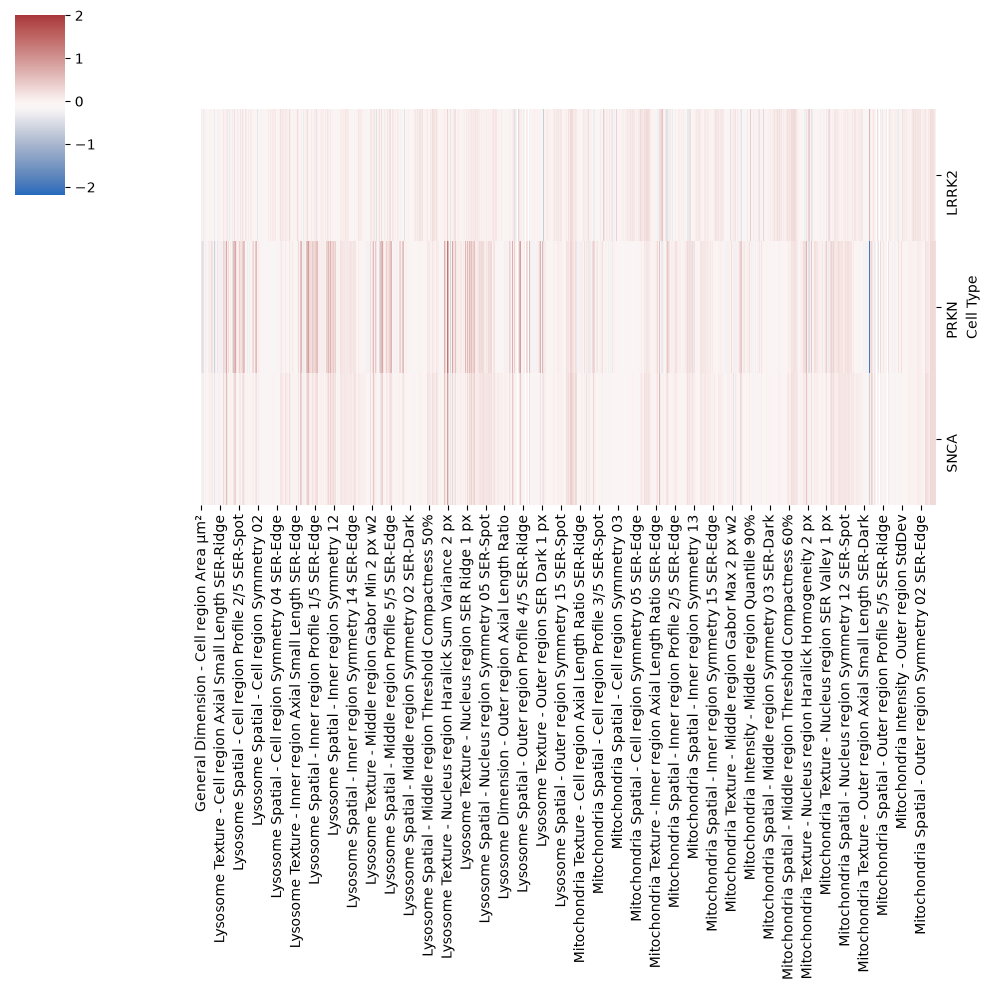

In [14]:
# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data_2,
    cmap='vlag',
    figsize=(10, 10),
    row_cluster=False,
    col_cluster=False,
)

## Begin adding additional labels

In [15]:
set(organelles)

{'General', 'Lysosome', 'Mitochondria'}

In [16]:
set(regions)

{'Cell region',
 'Inner region',
 'Middle region',
 'Nucleus region',
 'Outer region'}

In [17]:
set(star_types)

{'Axial', 'None', 'Radial', 'SER', 'Symmetry', 'Threshold'}

In [18]:
set(feature_types)

{'Dimension', 'Intensity', 'Spatial', 'Texture'}

In [19]:
set(ser_types)

{'Bright', 'Dark', 'Edge', 'Hole', 'None', 'Ridge', 'Saddle', 'Spot', 'Valley'}

In [20]:
len(ser_types)

1320

In [21]:
len(feature_types)

1320

In [22]:
len(star_types)

1320

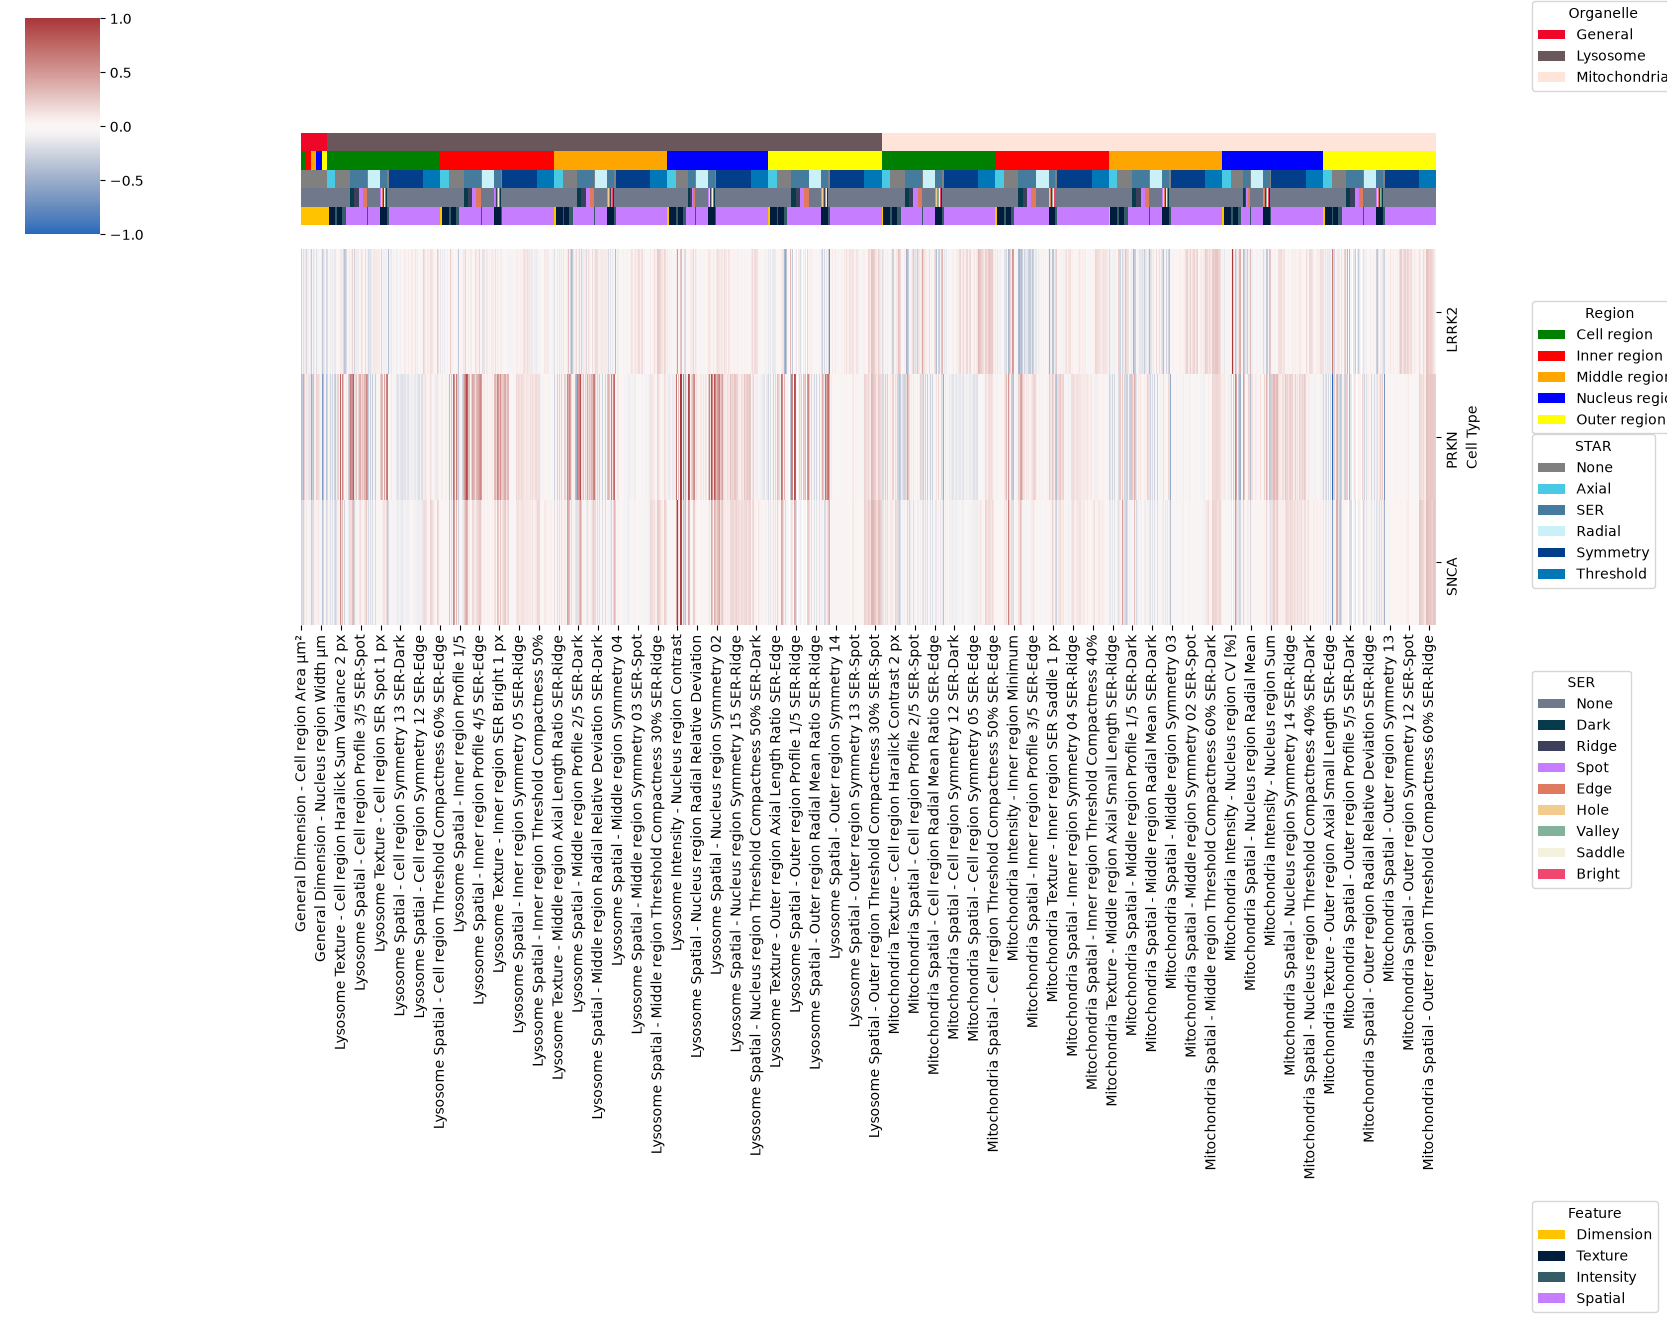

In [23]:
# Initialise an organelles array
organelle_colors = [

]

lut_organelle = {

}

for organelle in organelles:
    color = 'Grey'
    if organelle == 'General':
        color = "#ef072a"
    elif organelle == 'Mitochondria':
        color = '#ffe5d9'
    else:
        color = "#6A575C"

    lut_organelle[organelle] = color
    organelle_colors.append(color)

# Initialise a colours array
region_colors = [

]

lut = {

}


# Initialise a colours array for STAR
star_colors = [

]

lut_star = {

}
for star in star_types:
    if star == 'None':
        star_color = 'Grey'
    elif star == 'Symmetry':
        star_color = '#023e8a'
    elif star == 'Threshold':
        star_color = '#0077b6'
    elif star == 'Axial':
        star_color = '#48cae4'
    elif star == 'Radial':
        star_color = '#caf0f8'
    else:
        star_color = '#457b9d'

    lut_star[star] = star_color
    star_colors.append(star_color)
    


# Go over each region
for region in regions:
    if region == 'Nucleus region':
        region_color = 'Blue'
        lut['Nucleus region'] = 'Blue'
    elif region == 'Inner region':
        region_color = 'Red'
        lut['Inner region'] = 'Red'
    elif region == 'Middle region':
        region_color = 'Orange'
        lut['Middle region'] = 'Orange'
    elif region == 'Outer region':
        region_color = 'Yellow'
        lut['Outer region'] = 'Yellow'
    elif region == 'Cell region':
        region_color = 'Green'
        lut['Cell region'] = 'Green'

    lut[region] = region_color
    region_colors.append(region_color)

# Feature colours
feature_colours = []
lut_feature = {

}
for feature in feature_types:
    if feature == 'Intensity':
        feature_color = '#335c67'
    elif feature == 'Dimension':
        feature_color = '#ffc300'
    elif feature == 'Spatial':
        feature_color = '#c77dff'
    else:
        feature_color = '#001d3d'

    lut_feature[feature] = feature_color

    feature_colours.append(feature_color)


# SER colours
ser_colours = [

]

lut_ser = {

}

for ser in ser_types:
    if ser == 'Saddle':
        ser_color = '#f4f1de'
    elif ser == 'Edge':
        ser_color = '#e07a5f'
    elif ser == 'Ridge':
        ser_color = '#3d405b'
    elif ser == 'Valley':
            ser_color = '#81b29a'
    elif ser == 'Hole':
            ser_color = '#f2cc8f'
    elif ser == 'Spot':
        ser_color = '#c77dff'
    elif ser == 'Dark':
        ser_color = '#073b4c'
    elif ser == 'Bright':
        ser_color = '#ef476f'
    else:
        ser_color = '#70798c'

    lut_ser[ser] = ser_color

    ser_colours.append(ser_color)    



# Figure this legend part out later
handles = [Patch(facecolor=lut[name]) for name in lut]
handles_2 = [Patch(facecolor=lut_star[name]) for name in lut_star]
handles_3 = [Patch(facecolor=lut_feature[name]) for name in lut_feature]
handles_4 = [Patch(facecolor=lut_organelle[name]) for name in lut_organelle]
handles_5 = [Patch(facecolor=lut_ser[name]) for name in lut_ser]

g = sns.clustermap(
    heatmap_data_2,
    cmap='vlag',
    center=0,
    vmin=-1,  # Adjust based on your typical log2FC range
    vmax=1,
    figsize=(15, 12),
    row_cluster=False,
    col_cluster=False,
    col_colors=[organelle_colors, region_colors, star_colors, ser_colours, feature_colours]
)

pos = g.ax_heatmap.get_position()

# 3. Define how much gap we want to add
gap = 0.02 

g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height - gap])

ax= plt.gca()
# 1. First Legend (Organelle) - Top Left of anchor
leg1 = plt.legend(handles_4, lut_organelle, title='Organelle',
                  bbox_to_anchor=(1.02, 1.0), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg1) # Pin it so it doesn't get overwritten

# 2. Second Legend (Region) - Shifted down vertically (e.g., to y=0.75)
leg2 = plt.legend(handles, lut, title='Region',
                  bbox_to_anchor=(1.02, 0.75), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg2)

# 3. Third Legend (Feature) - Shifted further down (e.g., to y=0.50)
leg3 = plt.legend(handles_2, lut_star, title='STAR',
                  bbox_to_anchor=(1.02, 0.50), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg3)

# SER
leg5 = plt.legend(handles_5, lut_ser, title='SER',
                  bbox_to_anchor=(1.02, 0.25), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg5)

# 4. Fourth Legend (STAR) - Placed at the bottom right corner
leg4 = plt.legend(handles_3, lut_feature, title='Feature',
                  bbox_to_anchor=(1.02, 0.0), bbox_transform=plt.gcf().transFigure, loc='upper left')






In [24]:
heatmap_data_2[heatmap_data_2.columns[heatmap_data_2.std() == 0]]

""
Cell Type
LRRK2
PRKN
SNCA


In [25]:
heatmap_data_2 = heatmap_data_2.astype('float')
print(np.isinf(heatmap_data_2).sum().sum())
print(heatmap_data_2.isna().sum().sum())
heatmap_data_2 = heatmap_data_2.dropna(axis=1)
print(heatmap_data_2.isna().sum().sum())
# print(heatmap_data_2)
zero_variance_cols = heatmap_data_2.columns[heatmap_data_2.std() == 0].tolist()
new_heatmap_data_2 = heatmap_data_2
new_heatmap_data_2 = new_heatmap_data_2.drop(columns=zero_variance_cols)

0
35
0


In [26]:
heatmap_data_2

,General Dimension - Cell region Area µm²,General Dimension - Cell region Length µm,General Dimension - Cell region Perimeter µm,General Dimension - Cell region Ratio Width to Length,General Dimension - Cell region Roundness,General Dimension - Cell region Width µm,General Dimension - Inner region Area µm²,General Dimension - Inner region Length µm,General Dimension - Inner region Perimeter µm,General Dimension - Inner region Ratio Width to Length,...,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Ridge,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Ridge,Mitochondria Spatial - Outer region Threshold Compactness 30% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 40% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Spot,Mitochondria Spatial - Outer region Threshold Compactness 30% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 40% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 50% SER-Edge,Mitochondria Spatial - Outer region Threshold Compactness 60% SER-Edge
Cell Type,,,,,,,,,,,,,,,,,,,,,
LRRK2,-0.275505,-0.006789,-0.179010,0.019191,0.077769,-0.109803,-0.224429,-0.092225,-0.080890,-0.030222,...,0.238360,0.194690,0.218276,0.216056,0.198819,0.173173,0.130418,0.086891,0.034592,-0.026423
PRKN,-0.378552,-0.304262,-0.436568,0.205498,0.215335,-0.070413,-0.136457,0.064436,0.135974,-0.162766,...,0.265425,0.244632,0.260526,0.258070,0.255561,0.242244,0.249601,0.238351,0.218806,0.187906
SNCA,-0.234904,-0.182164,-0.236909,0.122430,0.101694,-0.050213,-0.104806,0.003168,0.058524,-0.054623,...,0.281143,0.252799,0.264683,0.254156,0.233827,0.205428,0.268035,0.261941,0.235277,0.192257


In [27]:
heatmap_data[zero_variance_cols]

""
Cell Type
Control
LRRK2
PRKN
SNCA


In [28]:
print(zero_variance_cols)

[]


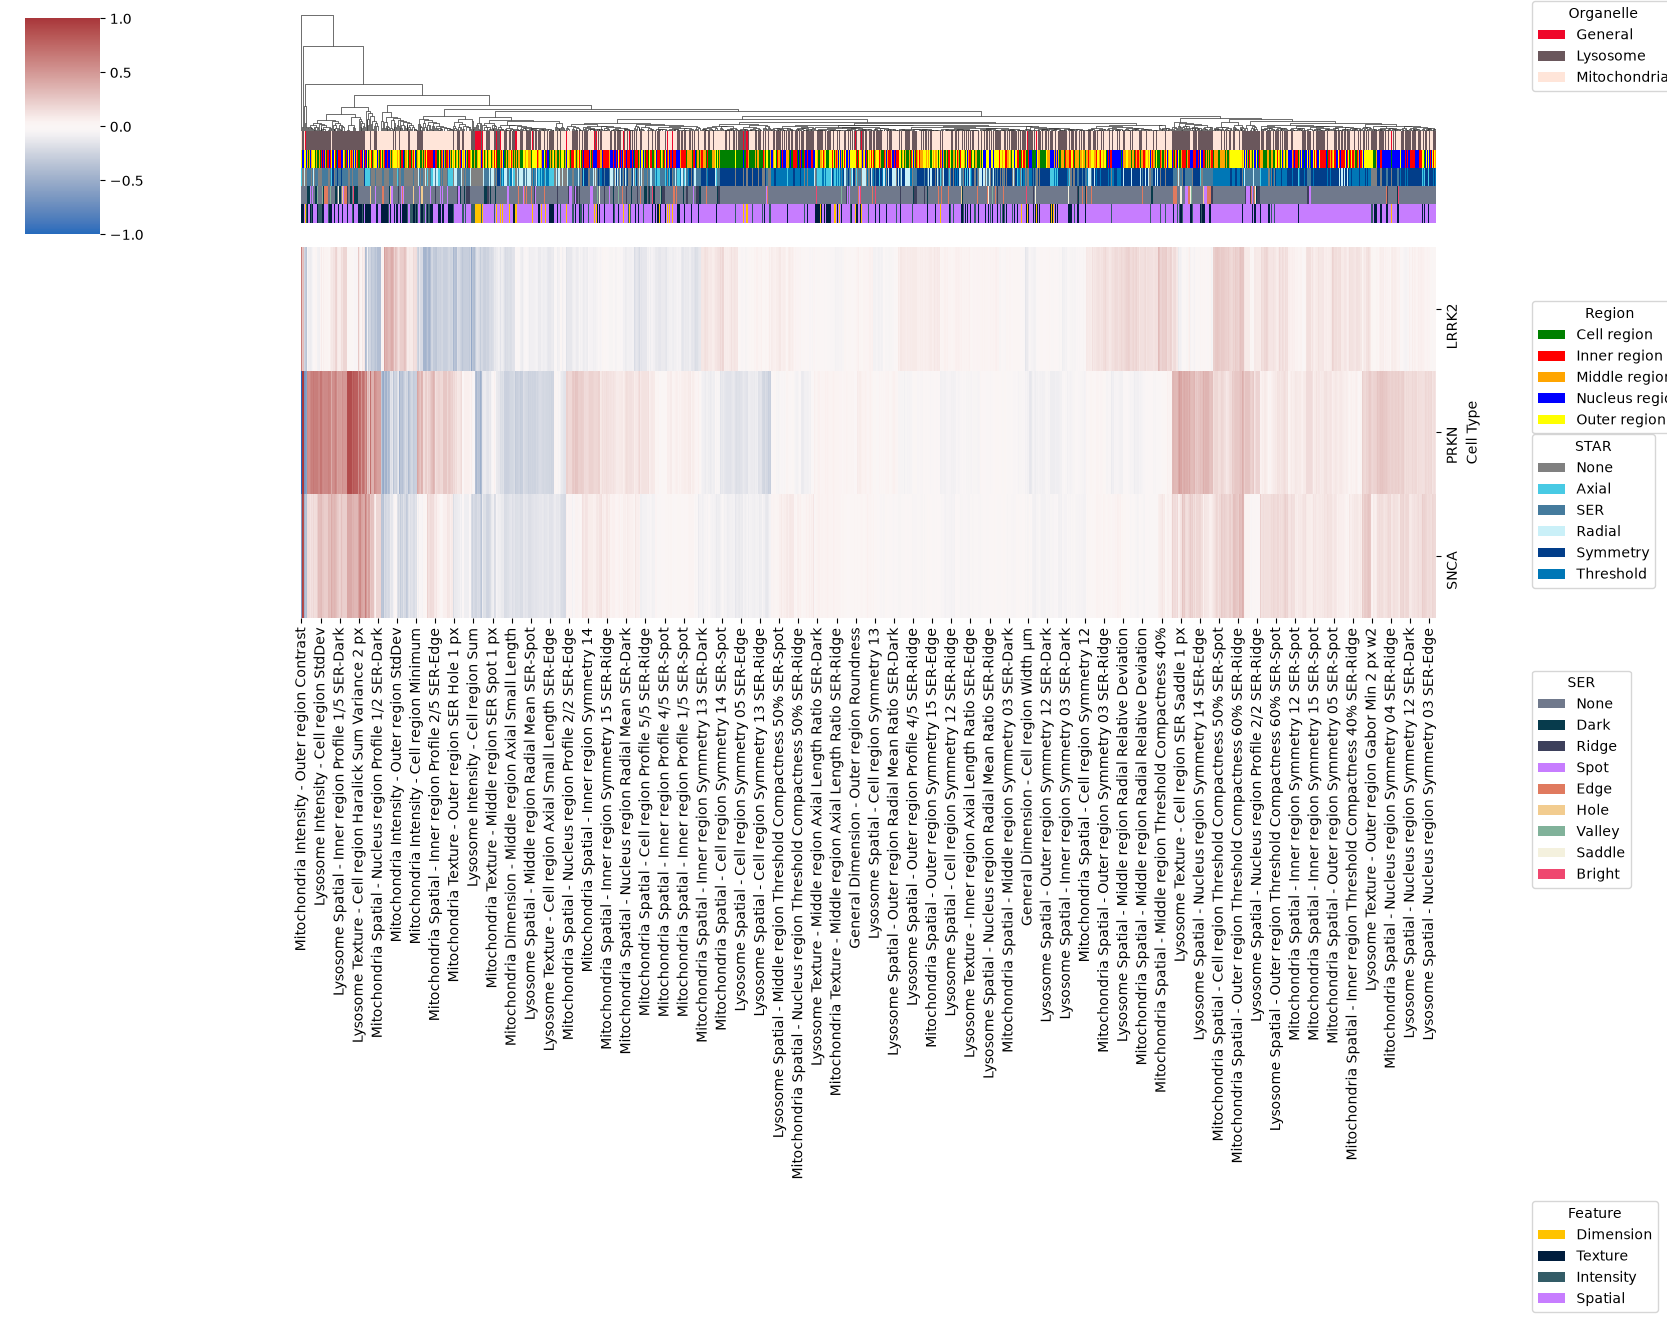

In [29]:
g = sns.clustermap(
    new_heatmap_data_2,
    cmap='vlag',
    figsize=(15, 12),
    center=0,
    vmin=-1,  # Adjust based on your typical log2FC range
    vmax=1,
    row_cluster=False,
    col_cluster=True,
    col_colors=[organelle_colors, region_colors, star_colors, ser_colours, feature_colours]
)

pos = g.ax_heatmap.get_position()

# 3. Define how much gap we want to add
gap = 0.02 

g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height - gap])

ax= plt.gca()
# 1. First Legend (Organelle) - Top Left of anchor
leg1 = plt.legend(handles_4, lut_organelle, title='Organelle',
                  bbox_to_anchor=(1.02, 1.0), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg1) # Pin it so it doesn't get overwritten

# 2. Second Legend (Region) - Shifted down vertically (e.g., to y=0.75)
leg2 = plt.legend(handles, lut, title='Region',
                  bbox_to_anchor=(1.02, 0.75), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg2)

# 3. Third Legend (Feature) - Shifted further down (e.g., to y=0.50)
leg3 = plt.legend(handles_2, lut_star, title='STAR',
                  bbox_to_anchor=(1.02, 0.50), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg3)

# The SER feature
leg5 = plt.legend(handles_5, lut_ser, title='SER',
                  bbox_to_anchor=(1.02, 0.25), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg5)

# 4. Fourth Legend (STAR) - Placed at the bottom right corner
leg4 = plt.legend(handles_3, lut_feature, title='Feature',
                  bbox_to_anchor=(1.02, 0.0), bbox_transform=plt.gcf().transFigure, loc='upper left')


